<a href="https://colab.research.google.com/github/niniqoiii/Georgian-Spellcheck/blob/main/data_and_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Georgian Spellchecker: Data and Training

This notebook builds a character-level sequence-to-sequence spellchecker for Georgian words.

The model learns mappings like:

- `გამარჰონა → გამარჯობა`
- `პროგამა → პროგრამა`
- `თბილისი → თბილისი`

It uses a recurrent encoder-decoder GRU model and works at character level only.


In [2]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import torch

# Keep CPU training predictable and fast on normal laptops / Colab CPU.
torch.set_num_threads(1)

from spellchecker import (
    load_words, corrupt_word, make_pairs, build_vocab,
    train_model, correct_word, download_words_from_url
)


The project can run offline, but when internet is available the notebook can download the latest version from Drive. If the Drive file changes, rerunning this notebook refreshes the local dataset and retrains the model on the updated data.

The preprocessing rule is to keep only Georgian-script words and remove duplicates.


In [3]:
DATASET_URL = 'https://drive.google.com/file/d/1NnELSMHpI9ru6RgzGVT6wiIiTAjWKgj_/view?usp=sharing'
words_path = 'data/georgian_words.txt'

# Try to refresh the local dataset from Google Drive.
# If the notebook is run without internet, it falls back to the cached local file.
try:
    download_words_from_url(DATASET_URL, words_path)
    print('Dataset refreshed from Google Drive.')
except Exception as e:
    print('Could not download from Drive; using cached local dataset instead.')
    print(type(e).__name__, e)

words = load_words(words_path)
print('Unique words:', len(words))
print(words[:30])


Dataset refreshed from Google Drive.
Unique words: 37170
['ააგებინა', 'ააგეს', 'ააგო', 'აადვილებს', 'ააიპ', 'აამაღლა', 'აამეტყველა', 'აანაზღაურებს', 'ააოხრა', 'ააოხრეს', 'ააჟღერა', 'ააშენა', 'ააშენეს', 'ააცი', 'აახლოვებს', 'აბ', 'აბაახუდა', 'აბაზანებისთვის', 'აბაზანის', 'აბაზგები', 'აბაზგების', 'აბაზგებისა', 'აბაზგიასა', 'აბაკელიამ', 'აბაკელიას', 'აბანდებენ', 'აბანო', 'აბანოები', 'აბანოების', 'აბანოთუბანი']


## 2. Data generation

The model needs `(input_word, target_word)` pairs. The target is always the correct word.

I generate realistic synthetic typos using four common edit operations:

1. character deletion
2. character replacement
3. adjacent character swap
4. extra character insertion

I also include already-correct inputs, because the model must learn not to change words that are already correct.

In [4]:
random.seed(7)
for w in ['გამარჯობა', 'თბილისი', 'პროგრამა', 'საქართველო', 'კომპიუტერი']:
    print(w, '->', [corrupt_word(w, p_keep_correct=0.0) for _ in range(5)])

გამარჯობა -> ['ამარჯობა', 'გამარჰობა', 'ბამარჯობა', 'გმარჯობა', 'გმარჯობა']
თბილისი -> ['თბილთსი', 'თდილისი', 'თბიისი', 'თბლისი', 'ბთილისი']
პროგრამა -> ['პროგრბმა', 'როგრამა', 'პროგრანა', 'პროგრგამა', 'პრორამა']
საქართველო -> ['საქართვგლო', 'სქართველო', 'საქარზველო', 'სგქართველო', 'საქართვდლო']
კომპიუტერი -> ['კმპიუტერი', 'კპმპიუტერი', 'კომპიუტერკ', 'კომპისტერი', 'კომპიუტერთ']


In [5]:
pairs = make_pairs(words[:1000], variants_per_word=3)
print('Example training pairs:')
for pair in pairs[:20]:
    print(pair[0], '→', pair[1])

Example training pairs:
ალტერაციის → ალიტერაციის
ალაადსტური → ალადასტური
ანაში → ამაში
ათაბბაგებმა → ათაბაგებმა
ალფ → ალფ
აგროვეგდა → აგროვებდა
ანაურები → აზნაურები
აეტომატური → ავტომატური
აგერობული → აერობული
ათასწკეულთა → ათასწლეულთა
ამათაც → ამათცა
ანმათ → ამათ
აკვატოსიის → აკვატორიის
ლააგ → ალაგ
აელქსეი → ალექსეი
ააიტაციის → აგიტაციის
აკბადემიკოსი → აკადემიკოსი
ადუყებს → ადუღებს
აბაის → აბასის
აკმენ → აკმენე


## 3. Model design

I use an encoder-decoder GRU model. This is a good fit because the misspelled input and corrected output can have different lengths.

For example:

`პროგამა → პროგრამა`

The output is longer than the input because the missing `რ` must be inserted.

Special tokens:

- `<PAD>` for padding batches
- `<SOS>` for decoder start
- `<EOS>` for end of word
- `<UNK>` for unknown characters

In [6]:
stoi = build_vocab(words)
print('Vocabulary size:', len(stoi))
print(stoi)

Vocabulary size: 37
{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, 'ა': 4, 'ბ': 5, 'გ': 6, 'დ': 7, 'ე': 8, 'ვ': 9, 'ზ': 10, 'თ': 11, 'ი': 12, 'კ': 13, 'ლ': 14, 'მ': 15, 'ნ': 16, 'ო': 17, 'პ': 18, 'ჟ': 19, 'რ': 20, 'ს': 21, 'ტ': 22, 'უ': 23, 'ფ': 24, 'ქ': 25, 'ღ': 26, 'ყ': 27, 'შ': 28, 'ჩ': 29, 'ც': 30, 'ძ': 31, 'წ': 32, 'ჭ': 33, 'ხ': 34, 'ჯ': 35, 'ჰ': 36}


## 4. Training

The training function performs:

- train/validation split
- batching and padding
- teacher forcing with decoder input
- cross-entropy loss ignoring `<PAD>`
- tqdm progress bar for each epoch
- checkpoint saving when validation loss improves

This run uses **30 epochs** so the loss curve has enough points for the assignment report.


In [7]:
model, stoi, history = train_model(
    words_path=words_path,
    model_path='model/georgian_spellchecker.pt',
    epochs=30,
    batch_size=32,
    lr=0.001,
    max_words=2800
)


Epoch 1/30


Training:   0%|          | 0/315 [00:00<?, ?it/s]

Train Loss: 2.2877 | Val Loss: 1.9655
Learning Rate: 0.001000
✓ New best model saved (val_loss: 1.9655)

Epoch 2/30


Training:   0%|          | 0/315 [00:00<?, ?it/s]

Train Loss: 1.8263 | Val Loss: 1.6793
Learning Rate: 0.001000
✓ New best model saved (val_loss: 1.6793)

Epoch 3/30


...

Train Loss: 0.3054 | Val Loss: 0.4296
Learning Rate: 0.001000

Epoch 29/30


Training:   0%|          | 0/315 [00:00<?, ?it/s]

Train Loss: 0.2970 | Val Loss: 0.4125
Learning Rate: 0.001000
✓ New best model saved (val_loss: 0.4125)

Epoch 30/30


Training:   0%|          | 0/315 [00:00<?, ?it/s]

Train Loss: 0.2875 | Val Loss: 0.4139
Learning Rate: 0.001000



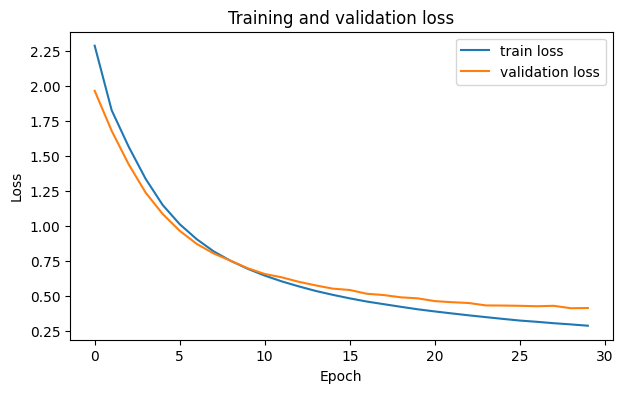

In [8]:
plt.figure(figsize=(7,4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

## 5. Save

The trained model is saved to:

`model/georgian_spellchecker.pt`

In [9]:
print(Path('model/georgian_spellchecker.pt').exists())

True
